# Anime Dataset - Feature Engineering

**Author:** Alexei Luchian  
**Date:** October 2025  
**Goal:** Transform cleaned data into ML-ready features  

---

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer, StandardScaler
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import ast

df = pd.read_csv('../data/processed/anime_clean.csv')

df['genres'] = df['genres'].apply(ast.literal_eval)
df['studios'] = df['studios'].apply(ast.literal_eval)

print(f"Loaded {len(df)} cleaned anime")
df.head(3)

Loaded 448 cleaned anime


,title,score,genres,episodes,synopsis,popularity,members,studios,year
0,Shingeki no Kyojin,8.56,"[Action, Award Winning, Drama, Suspense, Gore,...",25,"Centuries ago, mankind was slaughtered to near...",1,4241532,[Wit Studio],2013
1,Death Note,8.62,"[Supernatural, Suspense, Psychological, Shounen]",37,"Brutal murders, petty thefts, and senseless vi...",2,4182141,[Madhouse],2006
2,Fullmetal Alchemist: Brotherhood,9.10,"[Action, Adventure, Drama, Fantasy, Military, ...",64,After a horrific alchemy experiment goes wrong...,3,3585320,[Bones],2009


## Feature 1: One-Hot Encode Genres

### Problem:
ML can't understand text like "Action" or "Comedy"

### Solution:
Create binary columns for each genre

**Example:**
```
Before: genres = ['Action', 'Comedy']

After:  Action=1, Comedy=1, Drama=0, Romance=0, ...
```

This is called **one-hot encoding**

In [3]:
all_genres = set()
for genres in df['genres']:
    all_genres.update(genres)

print(f"Found {len(all_genres)} unique genres:")
print(sorted(all_genres))

mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df['genres'])
genres_df = pd.DataFrame(genres_encoded, columns=mlb.classes_, index=df.index)

print(f"\nCreated {len(mlb.classes_)} genre columns")
print("\nExample encoding:")
print(f"Anime: {df['title'].iloc[0]}")
print(f"Genres: {df['genres'].iloc[0]}")
print(f"Encoded: {genres_df.iloc[0][genres_df.iloc[0] == 1].index.tolist()}")

genres_df.head()

Found 73 unique genres:
['Action', 'Adult Cast', 'Adventure', 'Anthropomorphic', 'Avant Garde', 'Award Winning', 'Boys Love', 'CGDCT', 'Childcare', 'Combat Sports', 'Comedy', 'Crossdressing', 'Delinquents', 'Detective', 'Drama', 'Ecchi', 'Educational', 'Erotica', 'Fantasy', 'Gag Humor', 'Girls Love', 'Gore', 'Gourmet', 'Harem', 'High Stakes Game', 'Historical', 'Horror', 'Idols (Female)', 'Isekai', 'Iyashikei', 'Josei', 'Kids', 'Love Polygon', 'Love Status Quo', 'Mahou Shoujo', 'Martial Arts', 'Mecha', 'Medical', 'Military', 'Music', 'Mystery', 'Mythology', 'Organized Crime', 'Otaku Culture', 'Parody', 'Performing Arts', 'Psychological', 'Racing', 'Reincarnation', 'Reverse Harem', 'Romance', 'Samurai', 'School', 'Sci-Fi', 'Seinen', 'Shoujo', 'Shounen', 'Showbiz', 'Slice of Life', 'Space', 'Sports', 'Strategy Game', 'Super Power', 'Supernatural', 'Survival', 'Suspense', 'Team Sports', 'Time Travel', 'Urban Fantasy', 'Vampire', 'Video Game', 'Visual Arts', 'Workplace']

Created 73 genre 

,Action,Adult Cast,Adventure,Anthropomorphic,Avant Garde,Award Winning,Boys Love,CGDCT,Childcare,Combat Sports,...,Supernatural,Survival,Suspense,Team Sports,Time Travel,Urban Fantasy,Vampire,Video Game,Visual Arts,Workplace
0,1,0,0,0,0,1,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


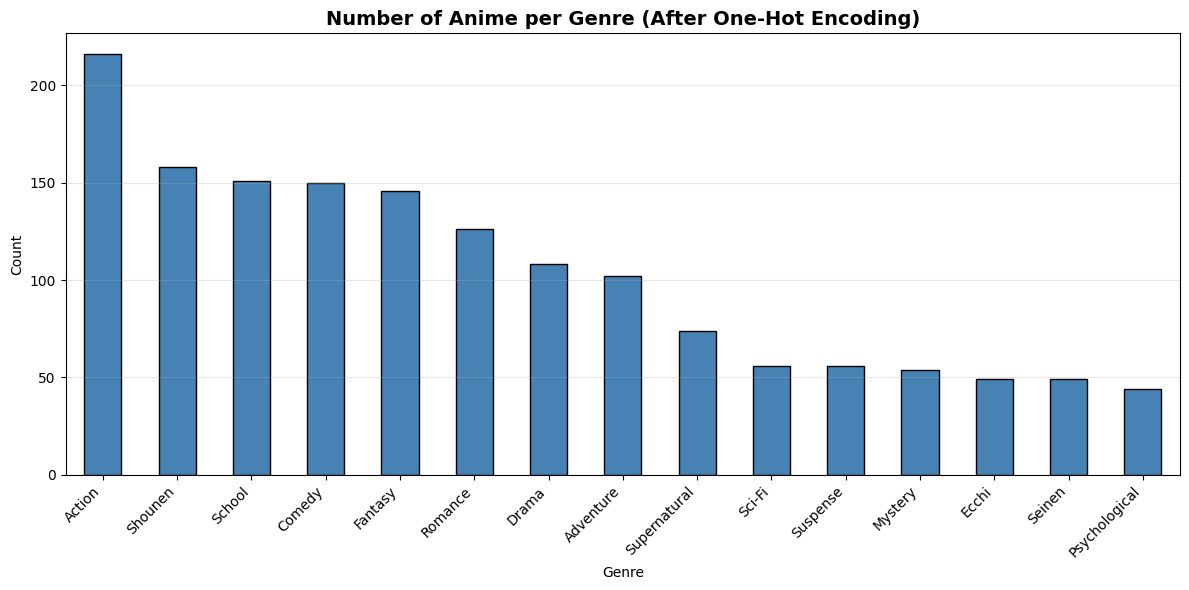

Most common genre: Action (216 anime)


In [4]:
genre_counts = genres_df.sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Anime per Genre (After One-Hot Encoding)', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Most common genre: {genre_counts.index[0]} ({genre_counts.iloc[0]} anime)")

## Feature 2: Normalize Numerical Features

### Problem:
Different scales confuse ML:
- Score: 5.0 - 9.0
- Popularity: 1 - 500
- Episodes: 1 - 500

ML thinks popularity is "more important" because numbers are bigger!

### Solution:
Scale everything to 0-1 range

**Example:**
```
Before: score = 8.5,  popularity = 250
After:  score = 0.75, popularity = 0.5
```

In [5]:
scaler = MinMaxScaler()

df['score_normalized'] = scaler.fit_transform(df[['score']])
df['popularity_normalized'] = scaler.fit_transform(df[['popularity']])
# Invert so higher value = more popular
df['popularity_normalized'] = 1 - df['popularity_normalized']

if 'episodes' in df.columns:
    df['episodes_normalized'] = df['episodes'].fillna(df['episodes'].median())
    df['episodes_normalized'] = scaler.fit_transform(df[['episodes_normalized']])

print("Normalized numerical features")
print("\nExample:")
print(f"Original score: {df['score'].iloc[0]} → Normalized: {df['score_normalized'].iloc[0]:.3f}")
print(f"Original popularity: {df['popularity'].iloc[0]} → Normalized: {df['popularity_normalized'].iloc[0]:.3f}")

Normalized numerical features

Example:
Original score: 8.56 → Normalized: 0.819
Original popularity: 1 → Normalized: 1.000


## Feature 3: Create Categorical Bins
Sometimes categories work better than exact numbers

**Example:**  
Instead of: popularity = 245 vs 246 (almost identical)  
Use tiers: S-Tier (Top 100) vs A-Tier (Top 500)

This reduces noise and helps ML find clearer patterns

In [6]:
df['popularity_tier'] = pd.cut(
    df['popularity'],
    bins = [0, 10, 50, 100, 500, 1000, 5000, 10000, 20000],
    labels = ['SS-Tier', 'S-Tier', 'A-Tier', 'B-Tier', 'C-Tier', 'D-Tier', 'E-Tier', 'F-Tier']
)

df['score_category'] = pd.cut(
    df['score'],
    bins=[0, 6.5, 7.5, 8.5, 10],
    labels=['Below Average', 'Average', 'Good', 'Excellent']
)

df['length_category'] = pd.cut(
    df['episodes'],
    bins=[0, 1, 13, 26, 52, 10000],
    labels=['Movie', 'Short', 'Season', 'Long', 'Very Long']
)

print("Created categorical features")
print("\nPopularity distribution:")
print(df['popularity_tier'].value_counts())
print("\nScore distribution:")
print(df['score_category'].value_counts())

Created categorical features

Popularity distribution:
popularity_tier
C-Tier    354
B-Tier     48
A-Tier     36
S-Tier     10
Name: count, dtype: int64

Score distribution:
score_category
Good             253
Average          125
Excellent         56
Below Average     14
Name: count, dtype: int64


In [7]:
tier_encoded = pd.get_dummies(df['popularity_tier'], prefix='tier')
score_cat_encoded = pd.get_dummies(df['score_category'], prefix='score_cat')
length_encoded = pd.get_dummies(df['length_category'], prefix='length')

print("Encoded categorical features")
print(f"\nTier columns: {list(tier_encoded.columns)}")
print(f"Score category columns: {list(score_cat_encoded.columns)}")
print(f"Length columns: {list(length_encoded.columns)}")

tier_encoded.head()

Encoded categorical features

Tier columns: ['tier_S-Tier', 'tier_A-Tier', 'tier_B-Tier', 'tier_C-Tier']
Score category columns: ['score_cat_Below Average', 'score_cat_Average', 'score_cat_Good', 'score_cat_Excellent']
Length columns: ['length_Movie', 'length_Short', 'length_Season', 'length_Long', 'length_Very Long']


,tier_S-Tier,tier_A-Tier,tier_B-Tier,tier_C-Tier
0,True,False,False,False
1,True,False,False,False
2,True,False,False,False
3,True,False,False,False
4,True,False,False,False


## Feature 4: Extract Features from Text

Synopsis contains valuable information!

**We can extract:**
- Keyword presence (school, magic, war, etc.)
- Sentiment (positive/negative tone)

In [8]:
df['synopsis_length'] = df['synopsis'].str.split().str.len()
df['synopsis_length_normalized'] = MinMaxScaler().fit_transform(df[['synopsis_length']])

keywords = {
    'school': [
        'school', 'student', 'academy', 'classroom', 'campus', 'teacher'
    ],
    
    'magic': [
        'magic', 'wizard', 'sorcerer', 'mage', 'spell', 'witch'
    ],
    
    'war': [
        'war', 'battlefield', 'soldier', 'military', 'invasion', 'army'
    ],
    
    'romance': [
        'romance', 'love story', 'romantic', 'couple', 'affection'
    ],
    
    'supernatural': [
        'supernatural', 'ghost', 'spirit', 'demon', 'vampire', 'haunted'
    ],
    
    'sci_fi': [
        'space', 'robot', 'cyborg', 'alien', 'mecha', 'time travel', 'future'
    ],
    
    'fantasy': [
        'dragon', 'sword', 'kingdom', 'knight', 'quest', 'magic realm'
    ],
    
    'sports': [
        'tournament', 'athlete', 'team', 'coach', 'match', 'training'
    ],
    
    'slice_of_life': [
        'school life', 'daily life', 'everyday life', 'coming of age'
    ],
    
    'mystery': [
        'mystery', 'detective', 'investigation', 'crime', 'clue', 'murder'
    ],
    
    'horror': [
        'horror', 'killer', 'nightmare', 'haunted', 'terror', 'curse'
    ],
    
    'comedy': [
        'comedy', 'funny', 'parody', 'humor', 'gag'
    ],
    
    'psychological': [
        'psychological', 'mind', 'insanity', 'mental', 'illusion', 'trauma'
    ]
}


for theme, words in keywords.items():
    pattern = '|'.join(words)  # Create regex: 'school|student|academy'
    df[f'has_{theme}'] = df['synopsis'].str.contains(pattern, case=False, na=False).astype(int)

print("Extracted text features")
print("\nSynopsis length stats:")
print(df['synopsis_length'].describe())
print(f"\nKeyword detection example (first anime):")
print(df['title'].iloc[0])
for theme in keywords.keys():
    print(f"  {theme}: {df[f'has_{theme}'].iloc[0]}")

Extracted text features

Synopsis length stats:
count    448.000000
mean     159.118304
std       33.556081
min       66.000000
25%      138.000000
50%      159.000000
75%      179.000000
max      261.000000
Name: synopsis_length, dtype: float64

Keyword detection example (first anime):
Shingeki no Kyojin
  school: 0
  magic: 0
  war: 1
  romance: 0
  supernatural: 0
  sci_fi: 0
  fantasy: 0
  sports: 0
  slice_of_life: 0
  mystery: 0
  horror: 0
  comedy: 0
  psychological: 0


## Feature 5: Time-Based Features

Release year matters!
- 2020s anime: Modern animation, streaming era
- 2000s anime: Digital animation boom
- 1990s anime: Hand-drawn classics

We can also calculate:
- Decades
- "Era" (old/classic/modern)
- Years since release

Created time-based features
Era distribution:
era
Classic        15
Golden Age     75
Modern        280
Current        78
Name: count, dtype: int64


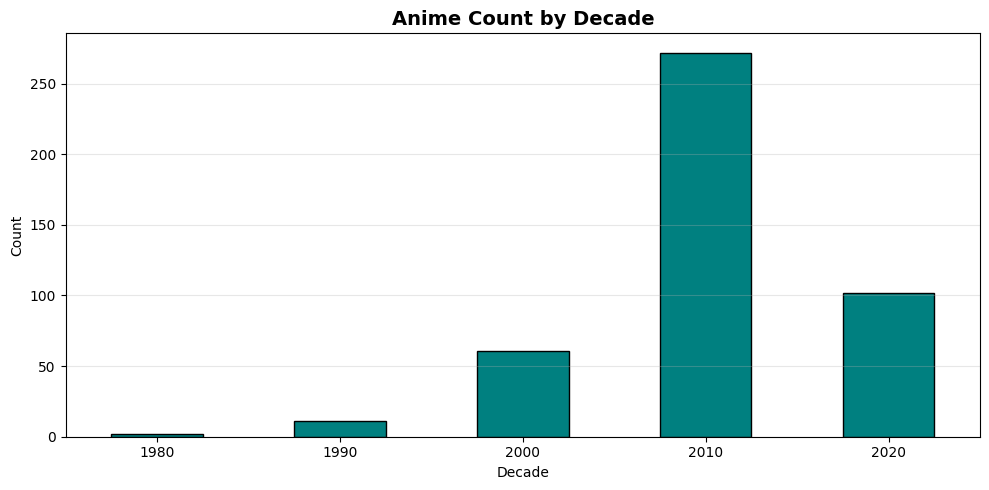

In [10]:
current_year = 2025
df['years_since_release'] = current_year - df['year']
df['years_since_release_normalized'] = MinMaxScaler().fit_transform(df[['years_since_release']])

df['decade'] = (df['year'] // 10) * 10

df['era'] = pd.cut(
    df['year'],
    bins=[1960, 2000, 2010, 2020, 2025],
    labels=['Classic', 'Golden Age', 'Modern', 'Current']
)

era_encoded = pd.get_dummies(df['era'], prefix='era')

print("Created time-based features")
print(f"Era distribution:")
print(df['era'].value_counts().sort_index())

plt.figure(figsize=(10, 5))
df['decade'].value_counts().sort_index().plot(kind='bar', color='teal', edgecolor='black')
plt.title('Anime Count by Decade', fontsize=14, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Combine All Features into Final Dataset

In [17]:
features_df = pd.concat([
    df[['title']].reset_index(drop=True),

    df[['score_normalized', 'popularity_normalized', 'episodes_normalized', 
        'synopsis_length_normalized', 'years_since_release_normalized']].reset_index(drop=True),
    
    genres_df.reset_index(drop=True),
    tier_encoded.reset_index(drop=True),
    score_cat_encoded.reset_index(drop=True),
    length_encoded.reset_index(drop=True),
    era_encoded.reset_index(drop=True),
    
    df[['has_school', 'has_magic', 'has_war', 'has_romance', 
    'has_supernatural', 'has_sci_fi', 'has_fantasy', 'has_sports', 
    'has_slice_of_life', 'has_mystery', 'has_horror', 
    'has_comedy', 'has_psychological']].reset_index(drop=True),
    
], axis=1)

print("Combined all features!")
print(f"\nFinal feature matrix shape: {features_df.shape}")
print(f"   → {features_df.shape[0]} anime")
print(f"   → {features_df.shape[1]} total features")

print(f"\nFeature columns created:")
print(f"   - Identifiers: 1 (title)")
print(f"   - Numerical features: 5")
print(f"   - Genre features: {len(genres_df.columns)}")
print(f"   - Tier features: {len(tier_encoded.columns)}")
print(f"   - Score category features: {len(score_cat_encoded.columns)}")
print(f"   - Length features: {len(length_encoded.columns)}")
print(f"   - Era features: {len(era_encoded.columns)}")
print(f"   - Text features: 6")
print(f"   Total: {features_df.shape[1]} columns")

features_df.head()

Combined all features!

Final feature matrix shape: (448, 109)
   → 448 anime
   → 109 total features

Feature columns created:
   - Identifiers: 1 (title)
   - Numerical features: 5
   - Genre features: 73
   - Tier features: 4
   - Score category features: 4
   - Length features: 5
   - Era features: 4
   - Text features: 6
   Total: 109 columns


,title,score_normalized,popularity_normalized,episodes_normalized,synopsis_length_normalized,years_since_release_normalized,Action,Adult Cast,Adventure,Anthropomorphic,...,has_romance,has_supernatural,has_sci_fi,has_fantasy,has_sports,has_slice_of_life,has_mystery,has_horror,has_comedy,has_psychological
0,Shingeki no Kyojin,0.819307,1.000000,0.042339,0.574359,0.307692,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Death Note,0.834158,0.997996,0.066532,0.528205,0.487179,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
2,Fullmetal Alchemist: Brotherhood,0.952970,0.995992,0.120968,0.569231,0.410256,1,0,1,0,...,0,0,1,1,1,0,0,0,0,0
3,One Punch Man,0.799505,0.993988,0.016129,0.512821,0.256410,1,1,0,0,...,0,0,1,0,1,0,0,0,0,0
4,Kimetsu no Yaiba,0.784653,0.991984,0.044355,0.564103,0.153846,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [15]:
anime_titles = features_df['title'].copy()
X = features_df.drop(columns=['title'])
y = X['score_normalized'].copy()
X_features_only = X.drop(columns=['score_normalized'])

print("Separated features and labels")
print(f"\nFeature matrix (X): {X.shape}")
print(f"   → {X.shape[0]} anime")
print(f"   → {X.shape[1]} features")

print(f"\nTarget variable (y): {y.shape}")
print(f"   → Predicting: anime scores")

print(f"\nFeatures without target (X_features_only): {X_features_only.shape}")
print(f"   → {X_features_only.shape[1]} features (excluding score)")

Separated features and labels

Feature matrix (X): (448, 108)
   → 448 anime
   → 108 features

Target variable (y): (448,)
   → Predicting: anime scores

Features without target (X_features_only): (448, 107)
   → 107 features (excluding score)


In [16]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)

features_df.to_csv('../data/processed/anime_features.csv', index=False)
print("Saved: anime_features.csv")

X.to_csv('../data/processed/X_features.csv', index=False)
print("Saved: X_features.csv")

X_features_only.to_csv('../data/processed/X_features_only.csv', index=False)
print("Saved: X_features_only.csv")

y.to_csv('../data/processed/y_target.csv', index=False, header=['score_normalized'])
print("Saved: y_target.csv")

title_mapping = pd.DataFrame({
    'index': range(len(anime_titles)),
    'title': anime_titles
})
title_mapping.to_csv('../data/processed/anime_titles.csv', index=False)
print("Saved: anime_titles.csv")

print(f"\n{'='*70}")
print("FEATURE ENGINEERING COMPLETE!")
print(f"{'='*70}")
print(f"\nSummary:")
print(f"   - {len(anime_titles)} anime processed")
print(f"   - {X.shape[1]} features created")
print(f"   - Ready for machine learning!")
print(f"\nFiles saved in: data/processed/")

Saved: anime_features.csv
Saved: X_features.csv
Saved: X_features_only.csv
Saved: y_target.csv
Saved: anime_titles.csv

FEATURE ENGINEERING COMPLETE!

Summary:
   - 448 anime processed
   - 108 features created
   - Ready for machine learning!

Files saved in: data/processed/
